# MAE — Test de chargement et inférence masquée

Modèle : `facebook/vit-mae-large` (ViT-L/16)  
Dataset : ImageNette (val)

In [6]:
pip install "torchvision>=0.15.0"

Note: you may need to restart the kernel to use updated packages.


In [7]:
pip install "transformers==4.40.0"

Note: you may need to restart the kernel to use updated packages.


## 1. Chargement du modèle

In [8]:
import torch
from transformers import ViTImageProcessor, ViTMAEModel

DEVICE   = 'cuda' if torch.cuda.is_available() else 'cpu'
# Chemin local vers le dossier téléchargé avec huggingface-cli
MODEL_PATH = './vit-mae-large'

print(f'Device : {DEVICE}')

processor = ViTImageProcessor(
    size={"height": 224, "width": 224},
    image_mean=[0.485, 0.456, 0.406],
    image_std=[0.229, 0.224, 0.225],
)

encoder = ViTMAEModel.from_pretrained(MODEL_PATH).to(DEVICE)
encoder.eval()

print('Modèle chargé')
print(f'  Dimension         : {encoder.config.hidden_size}')
print(f'  Blocs Transformer : {encoder.config.num_hidden_layers}')
print(f'  Têtes attention   : {encoder.config.num_attention_heads}')
print(f'  Taille patch      : {encoder.config.patch_size}')
print(f'  Mask ratio        : {encoder.config.mask_ratio}')


Device : cpu
Modèle chargé
  Dimension         : 1024
  Blocs Transformer : 24
  Têtes attention   : 16
  Taille patch      : 16
  Mask ratio        : 0.75


## 2. Chargement d'une image ImageNette

mkdir -p failed for path /home/ann/.config/matplotlib: [Errno 13] Permission denied: '/home/ann/.config/matplotlib'
Matplotlib created a temporary cache directory at /tmp/matplotlib-sevum57k because there was an issue with the default path (/home/ann/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Nombre d images train : 9469
Nombre d images val   : 3925
Classes : ['n01440764', 'n02102040', 'n02979186', 'n03000684', 'n03028079', 'n03394916', 'n03417042', 'n03425413', 'n03445777', 'n03888257']


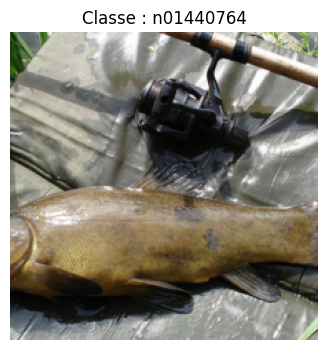

In [9]:
from torchvision.datasets import ImageFolder
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# Télécharger d'abord dans le terminal :
# wget https://s3.amazonaws.com/fast-ai-imageclas/imagenette.tgz
# tar -xzf imagenette.tgz

transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
])

dataset_train = ImageFolder(root='./imagenette/train', transform=transform)
dataset_val   = ImageFolder(root='./imagenette/val',   transform=transform)

print(f'Nombre d images train : {len(dataset_train)}')
print(f'Nombre d images val   : {len(dataset_val)}')
print(f'Classes : {dataset_train.classes}')

image_pil, label = dataset_val[0]

plt.figure(figsize=(4, 4))
plt.imshow(image_pil)
plt.title(f'Classe : {dataset_val.classes[label]}')
plt.axis('off')
plt.show()

## 3. Inférence avec masquage

In [10]:
def encode_masked(image, seed=None):
    """
    Encode une image avec masquage aleatoire a 75%.

    Args:
        image : image PIL (224x224)
        seed  : optionnel, fixe le tirage du masque

    Returns:
        patch_tokens : Tensor (49, 1024)  - z_i des patches visibles
        mask         : Tensor (196,)      - 0=visible, 1=masque
        ids_restore  : Tensor (196,)      - position originale de chaque patch
    """
    inputs = processor(images=image, return_tensors='pt')
    inputs = {k: v.to(DEVICE) for k, v in inputs.items()}

    noise = None
    if seed is not None:
        generator = torch.Generator().manual_seed(seed)
        noise = torch.rand(1, 196, generator=generator).to(DEVICE)

    with torch.no_grad():
        outputs = encoder(**inputs, noise=noise)

    # last_hidden_state : (1, 50, 1024) -> [CLS] + 49 patches visibles
    patch_tokens = outputs.last_hidden_state[0, 1:]  # (49, 1024)
    mask         = outputs.mask[0]                   # (196,)
    ids_restore  = outputs.ids_restore[0]            # (196,)

    return patch_tokens, mask, ids_restore

In [11]:
patch_tokens, mask, ids_restore = encode_masked(image_pil, seed=42)

print(f'Shape patch_tokens : {patch_tokens.shape}')        # (49, 1024)
print(f'Patches visibles   : {(mask == 0).sum().item()}')  # 49
print(f'Patches masques    : {mask.sum().item()}')         # 147
print(f'Norme moyenne z_i  : {patch_tokens.norm(dim=-1).mean().item():.3f}')

Shape patch_tokens : torch.Size([49, 1024])
Patches visibles   : 49
Patches masques    : 147.0
Norme moyenne z_i  : 19.222


## 4. Visualisation du masque appliqué

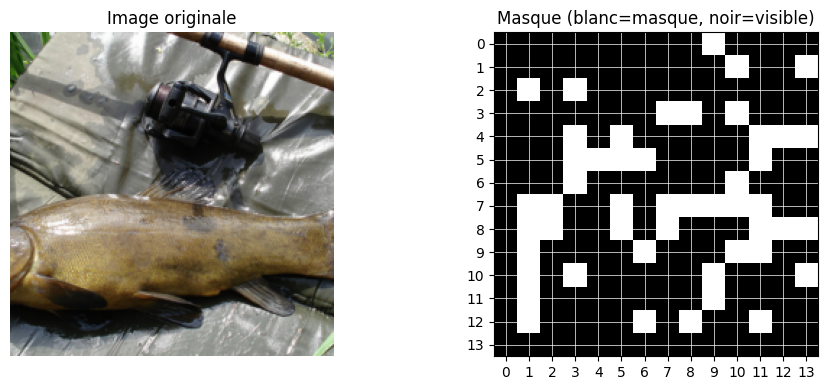

Ratio masque : 75.00%


In [12]:
import numpy as np

mask_grid = mask.cpu().numpy().reshape(14, 14)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].imshow(image_pil)
axes[0].set_title('Image originale')
axes[0].axis('off')

axes[1].imshow(mask_grid, cmap='gray_r', vmin=0, vmax=1)
axes[1].set_title('Masque (blanc=masque, noir=visible)')
axes[1].set_xticks(range(14))
axes[1].set_yticks(range(14))
axes[1].grid(True, color='white', linewidth=0.5)

plt.tight_layout()
plt.show()

print(f'Ratio masque : {mask_grid.mean():.2%}')  # ~75%

## 5. Position spatiale des tokens visibles

In [13]:
def token_positions(mask, ids_restore):
    """
    Retourne les indices originaux (0-195) des patches visibles
    et leur position (row, col) dans la grille 14x14.
    """
    visible_ids = ids_restore[mask == 0]  # (49,)

    positions = []
    for idx in visible_ids.tolist():
        row = idx // 14
        col = idx  % 14
        positions.append({'patch_id': idx, 'row': row, 'col': col})

    return positions


positions = token_positions(mask, ids_restore)

print(f'Nombre de tokens visibles : {len(positions)}')
print('5 premiers tokens visibles :')
for p in positions[:5]:
    print(f"  patch_id={p['patch_id']:3d}  row={p['row']}  col={p['col']}")

Nombre de tokens visibles : 49
5 premiers tokens visibles :
  patch_id= 26  row=1  col=12
  patch_id= 17  row=1  col=3
  patch_id= 39  row=2  col=11
  patch_id=  3  row=0  col=3
  patch_id= 10  row=0  col=10


## 6. Reproductibilité — même seed, même masque

In [14]:
tokens_a, mask_a, _ = encode_masked(image_pil, seed=42)
tokens_b, mask_b, _ = encode_masked(image_pil, seed=42)
tokens_c, mask_c, _ = encode_masked(image_pil, seed=99)

print('Meme seed  -> masques identiques :', torch.equal(mask_a, mask_b))       # True
print('Seeds diff -> masques differents :', not torch.equal(mask_a, mask_c))   # True
print('Meme seed  -> tokens identiques  :', torch.allclose(tokens_a, tokens_b)) # True

Meme seed  -> masques identiques : True
Seeds diff -> masques differents : True
Meme seed  -> tokens identiques  : True


## 7. Calcul de mean(z_i) sur K tirages

In [15]:
def mean_over_samplings(image, K=10):
    """
    Moyenne de mean(z_i) sur K tirages de masque independants.
    Retourne un vecteur image-level stable de dimension (1024,).
    """
    means = []
    for k in range(K):
        patch_tokens, _, _ = encode_masked(image, seed=k)
        means.append(patch_tokens.mean(dim=0))  # (1024,)

    return torch.stack(means).mean(dim=0)  # (1024,)


z_image = mean_over_samplings(image_pil, K=10)

print(f'Representation image-level : {z_image.shape}')  # (1024,)
print(f'Norme                      : {z_image.norm().item():.3f}')

Representation image-level : torch.Size([1024])
Norme                      : 6.967
